# O1 brute-force three-stage depth policies

Analysis of all 64 schedules over depths `{5, 10, 15, 20}` for stages 1–250, 251–600, and 601–1000. Rankings use final simple regret (lower is better). Across-seed top policies are selected on these same five seeds, so their comparison is exploratory.

In [1]:
from __future__ import annotations
import itertools, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DEPTHS = (5, 10, 15, 20)
SEEDS = tuple(range(5))
STAGES = ('trials 1–250', 'trials 251–600', 'trials 601–1000')
EXPECTED = set(itertools.product(DEPTHS, repeat=3))
candidates = [Path.cwd(), Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/04_02_no_size']
HERE = next((p for p in candidates if (p / 'o1_depth_runner.py').exists()), None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())

/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/04_02_no_size


## Load, validate, and report completeness

In [2]:
rows, curves = [], {}
for family in ('policies', 'fixed'):
    for path in sorted((OUTPUT / family).rglob('trajectory.json')):
        data = json.loads(path.read_text())
        schedule = tuple(map(int, data['depth_schedule']))
        best = np.asarray(data['best_regret'], float)
        key = (family, data['policy'], int(data['smac_seed']))
        if key in curves: raise ValueError(f'Duplicate trajectory: {key}')
        curves[key] = best
        rows.append({
            'family': family, 'policy': data['policy'], 'seed': int(data['smac_seed']),
            'd1': schedule[0], 'd2': schedule[1], 'd3': schedule[2], 'schedule': schedule,
            'final_regret': float(best[-1]), 'mean_regret': float(best.mean()),
            'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
            'n_trials': int(data['n_trials']), 'problem_seed': int(data['problem_seed']),
            'pythonhashseed': str(data['pythonhashseed']),
            'min_samples_leaf': int(data['min_samples_leaf']),
            'min_samples_split': int(data['min_samples_split']), 'path': path,
        })
results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No results below {OUTPUT}; jobs are unfinished or failed.')
bad = results.query("n_trials != 1000 or problem_seed != 52 or pythonhashseed != '12345' or min_samples_leaf != 1 or min_samples_split != 1")
if not bad.empty: display(bad); raise ValueError('Incompatible trajectory metadata.')
dynamic = results.query("family == 'policies'").copy()
fixed = results.query("family == 'fixed'").copy()
counts = dynamic.groupby('policy')['seed'].nunique()
complete_names = set(counts[counts == 5].index)
fixed_counts = fixed.groupby('policy')['seed'].nunique() if not fixed.empty else pd.Series(dtype=int)
complete_fixed = set(fixed_counts[fixed_counts == 5].index)
print(f'Loaded {len(dynamic)}/320 dynamic and {len(fixed)}/20 fixed trajectories.')
print(f'Complete schedules: {len(complete_names)}/64; complete fixed baselines: {len(complete_fixed)}/4')
print('Missing schedules:', sorted(EXPECTED - set(dynamic['schedule'])))
display(counts.value_counts().sort_index().rename_axis('completed seeds').to_frame('policies'))

Loaded 320/320 dynamic and 20/20 fixed trajectories.
Complete schedules: 64/64; complete fixed baselines: 4/4
Missing schedules: []


,policies
completed seeds,
5,64


## Top 5 and top 10 policies for each seed

In [3]:
def top_for_seed(seed, n):
    table = dynamic.query('seed == @seed').sort_values(['final_regret', 'mean_regret', 'policy']).head(n)
    table = table[['policy', 'd1', 'd2', 'd3', 'final_regret', 'mean_regret', 'log_auc']].reset_index(drop=True)
    table.index = np.arange(1, len(table) + 1); table.index.name = 'rank'
    return table
for seed in SEEDS:
    print(f'\nSeed {seed}: top 5'); display(top_for_seed(seed, 5))
    print(f'Seed {seed}: top 10'); display(top_for_seed(seed, 10))


Seed 0: top 5


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_10_20,5,10,20,6298.079774,70686.738136,4.684608
2,depth_policy_10_15_20,10,15,20,6740.617751,57291.773561,4.564894
3,depth_policy_15_20_20,15,20,20,7010.286256,58749.409846,4.571099
4,depth_policy_15_5_10,15,5,10,7800.746564,55122.594305,4.507894
5,depth_policy_5_15_20,5,15,20,8035.045596,57182.158130,4.491463


Seed 0: top 10


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_10_20,5,10,20,6298.079774,70686.738136,4.684608
2,depth_policy_10_15_20,10,15,20,6740.617751,57291.773561,4.564894
3,depth_policy_15_20_20,15,20,20,7010.286256,58749.409846,4.571099
4,depth_policy_15_5_10,15,5,10,7800.746564,55122.594305,4.507894
5,depth_policy_5_15_20,5,15,20,8035.045596,57182.158130,4.491463
6,depth_policy_20_15_10,20,15,10,8448.614262,55834.072714,4.527310
7,depth_policy_10_10_20,10,10,20,8894.839379,49300.923615,4.452661
8,depth_policy_15_15_20,15,15,20,8900.379625,56673.835556,4.534484
9,depth_policy_20_15_20,20,15,20,9106.155809,56264.109676,4.543798



Seed 1: top 5


...

,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_10_5_15,10,5,15,4114.010365,46206.057880,4.441396
2,depth_policy_20_20_20,20,20,20,4487.770579,57194.796794,4.615477
3,depth_policy_10_10_10,10,10,10,4911.622899,45504.314725,4.422105
4,depth_policy_10_10_15,10,10,15,5416.953525,45874.423560,4.448179
5,depth_policy_5_10_15,5,10,15,7178.115684,53545.266354,4.421225
6,depth_policy_10_15_10,10,15,10,7764.778222,49904.175255,4.536427
7,depth_policy_10_20_10,10,20,10,9113.235604,43641.923810,4.399018
8,depth_policy_10_5_10,10,5,10,9316.288418,47171.247658,4.480514
9,depth_policy_10_15_20,10,15,20,9326.636456,49726.228321,4.529891



Seed 4: top 5


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_15_20,5,15,20,3251.104242,36501.381304,4.285863
2,depth_policy_10_10_15,10,10,15,5717.210731,66177.098052,4.577855
3,depth_policy_10_20_15,10,20,15,7655.773643,61695.854703,4.530458
4,depth_policy_10_5_10,10,5,10,7816.335374,62014.870629,4.570504
5,depth_policy_5_10_20,5,10,20,9530.737480,42490.835367,4.484419


Seed 4: top 10


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_15_20,5,15,20,3251.104242,36501.381304,4.285863
2,depth_policy_10_10_15,10,10,15,5717.210731,66177.098052,4.577855
3,depth_policy_10_20_15,10,20,15,7655.773643,61695.854703,4.530458
4,depth_policy_10_5_10,10,5,10,7816.335374,62014.870629,4.570504
5,depth_policy_5_10_20,5,10,20,9530.737480,42490.835367,4.484419
6,depth_policy_20_15_20,20,15,20,10218.566759,61447.707534,4.520507
7,depth_policy_10_20_10,10,20,10,10394.049989,62249.965483,4.557835
8,depth_policy_5_15_10,5,15,10,10456.069831,37519.546599,4.366384
9,depth_policy_15_5_10,15,5,10,10458.870529,61560.124229,4.554222


## Per-seed depth frequencies among the top 5 and top 10

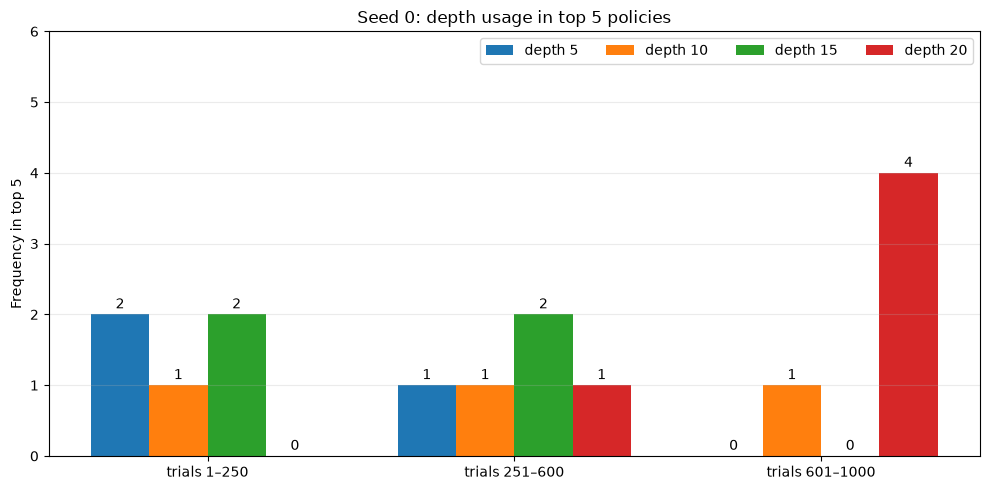

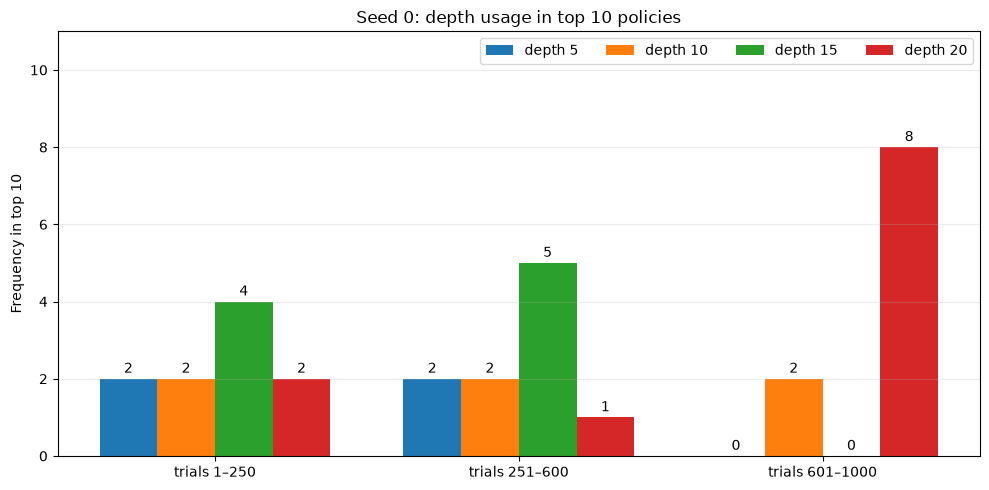

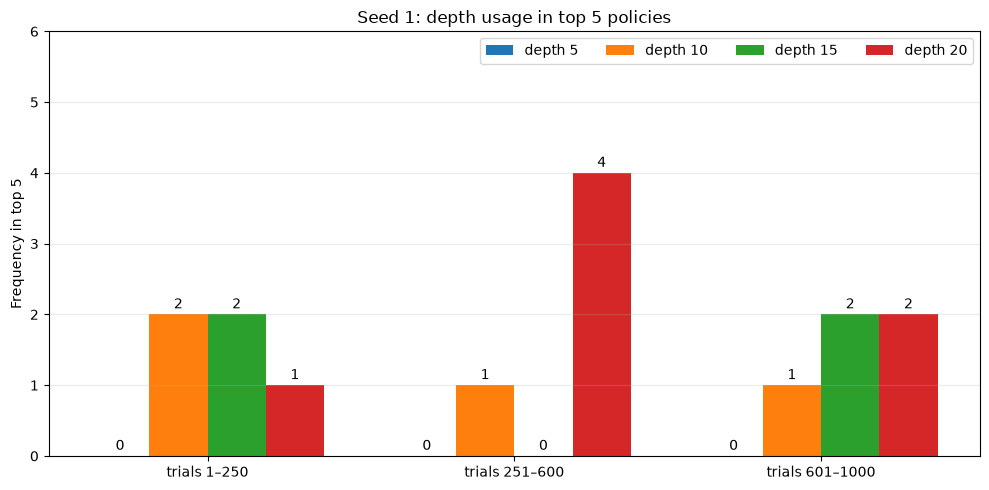

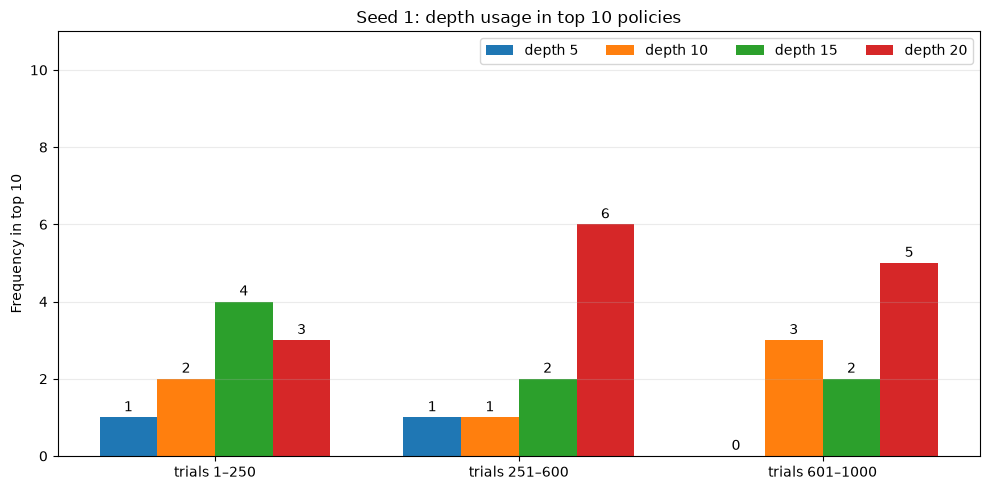

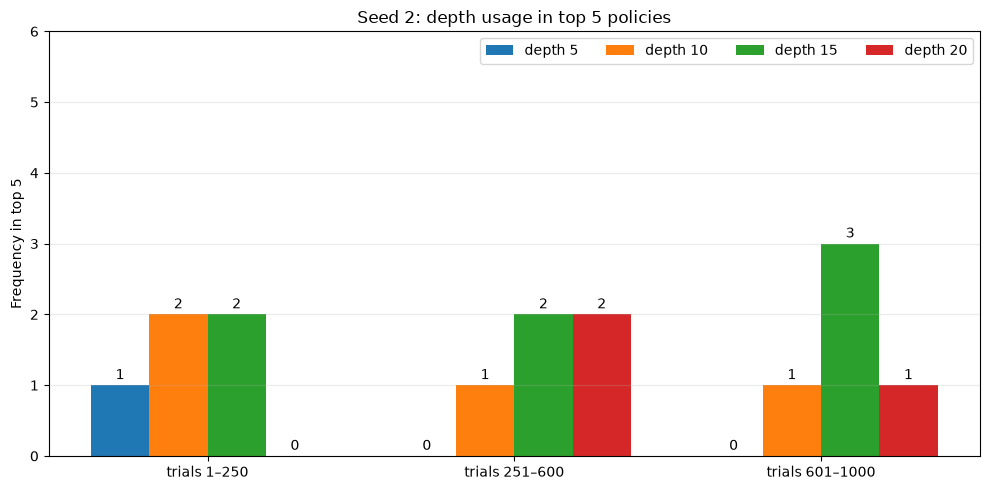

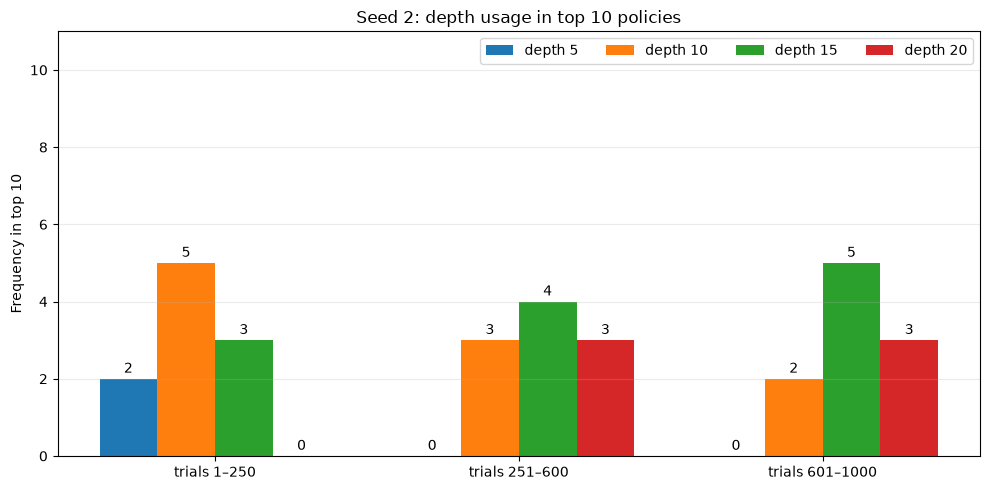

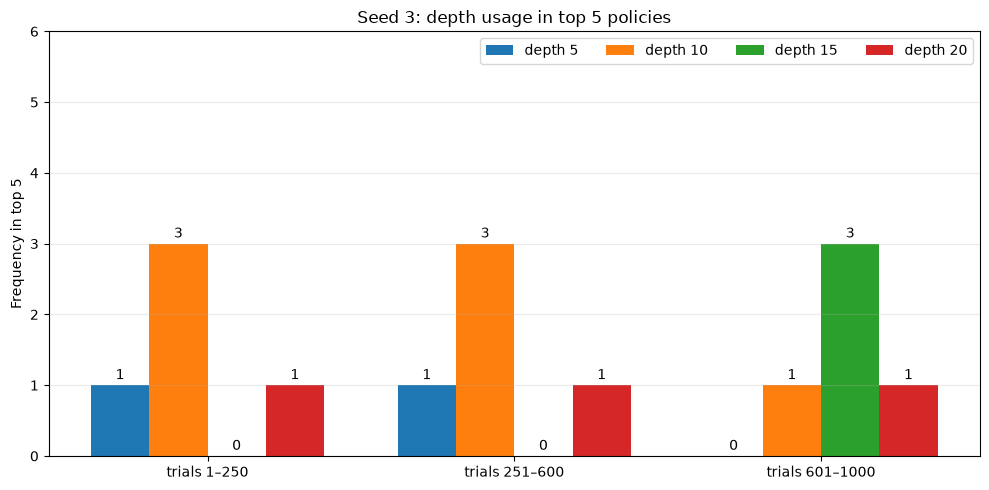

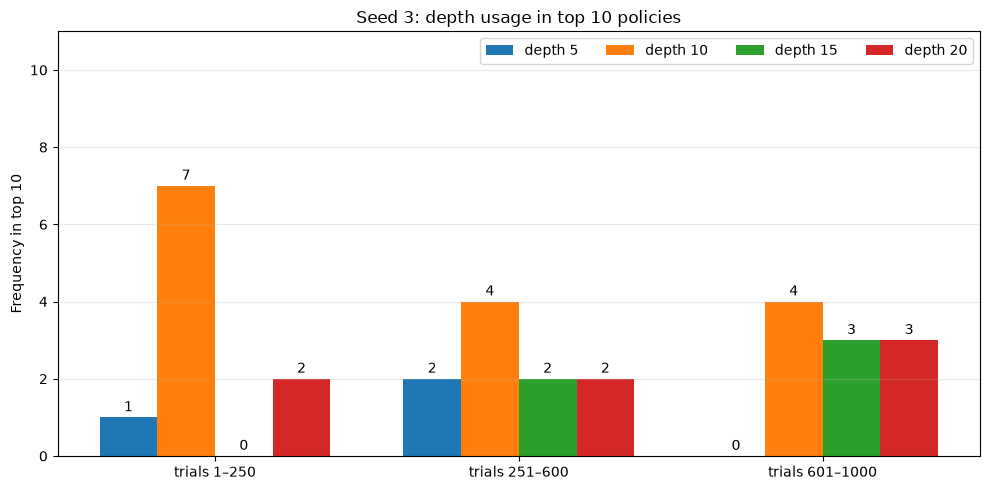

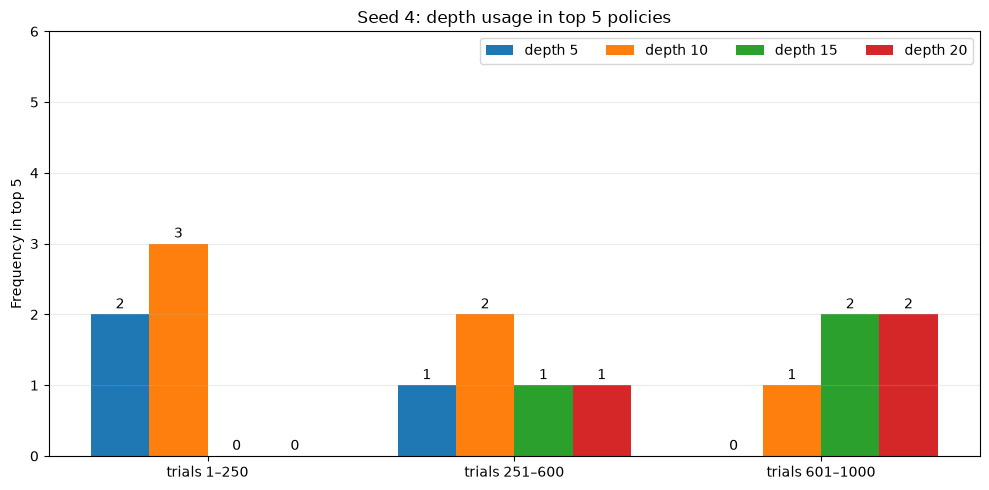

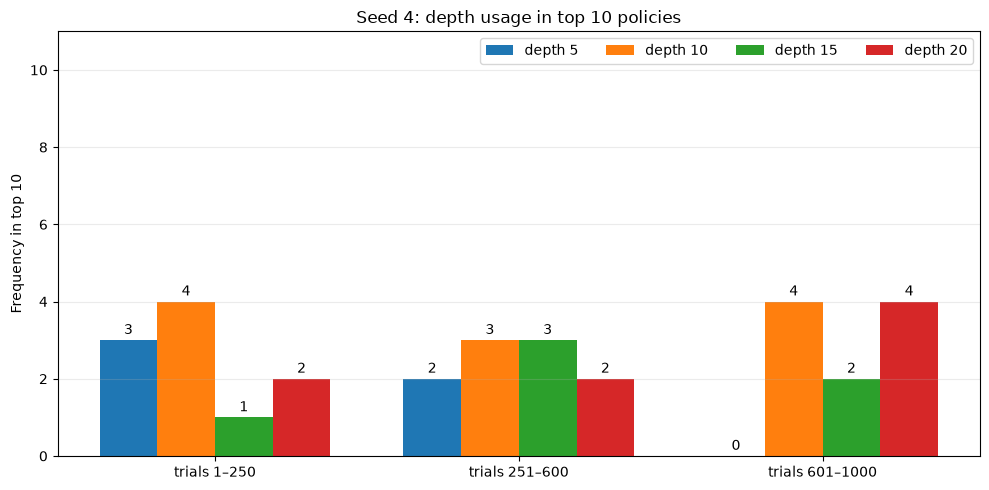

In [4]:
def frequency_plot(seed, n):
    selected = top_for_seed(seed, n); x = np.arange(3); width = 0.19
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, depth in enumerate(DEPTHS):
        values = [int((selected[f'd{stage}'] == depth).sum()) for stage in (1, 2, 3)]
        bars = ax.bar(x + (i - 1.5) * width, values, width, label=f'depth {depth}')
        ax.bar_label(bars, padding=2)
    ax.set_xticks(x, STAGES); ax.set_ylim(0, n + 1); ax.set_ylabel(f'Frequency in top {n}')
    ax.set_title(f'Seed {seed}: depth usage in top {n} policies'); ax.legend(ncol=4); ax.grid(axis='y', alpha=.25)
    plt.tight_layout(); plt.show()
for seed in SEEDS:
    frequency_plot(seed, 5); frequency_plot(seed, 10)

## Top five policies across seeds

In [5]:
complete = dynamic[dynamic.policy.isin(complete_names)].copy()
summary = (complete.groupby(['policy', 'd1', 'd2', 'd3'], as_index=False)
    .agg(mean_final=('final_regret','mean'), std_final=('final_regret','std'), median_final=('final_regret','median'), mean_regret=('mean_regret','mean'), mean_log_auc=('log_auc','mean'), seeds=('seed','nunique'))
    .sort_values(['mean_final','mean_regret','policy']).reset_index(drop=True))
summary.index = np.arange(1, len(summary)+1); summary.index.name = 'rank'
top5 = summary.head(5).copy(); display(top5)
print('Top 10 by full-trajectory log-regret AUC:')
display(summary.sort_values(['mean_log_auc','mean_final']).head(10))

,policy,d1,d2,d3,mean_final,std_final,median_final,mean_regret,mean_log_auc,seeds
rank,,,,,,,,,,
1,depth_policy_10_10_15,10,10,15,10399.945371,6222.719825,9669.539650,53368.631276,4.508517,5
2,depth_policy_5_15_20,5,15,20,10513.741443,5952.781014,10530.768258,57629.025006,4.527555,5
3,depth_policy_10_15_20,10,15,20,10918.089747,4458.157419,9326.636456,58022.046197,4.594672,5
4,depth_policy_10_20_15,10,20,15,11362.352915,2393.637753,11218.375100,55348.474228,4.547167,5
5,depth_policy_20_20_20,20,20,20,11416.309177,4748.481538,11531.909083,56647.848581,4.574251,5


Top 10 by full-trajectory log-regret AUC:


,policy,d1,d2,d3,mean_final,std_final,median_final,mean_regret,mean_log_auc,seeds
rank,,,,,,,,,,
1,depth_policy_10_10_15,10,10,15,10399.945371,6222.719825,9669.539650,53368.631276,4.508517,5
8,depth_policy_10_10_10,10,10,10,11846.753856,4746.117032,14828.859134,53210.039189,4.512352,5
12,depth_policy_10_20_10,10,20,10,12546.383636,8508.822329,9548.035819,54789.513534,4.525785,5
2,depth_policy_5_15_20,5,15,20,10513.741443,5952.781014,10530.768258,57629.025006,4.527555,5
10,depth_policy_10_10_20,10,10,20,12360.466699,2305.516873,12454.167329,53934.762725,4.536475,5
9,depth_policy_20_10_20,20,10,20,11899.176671,1876.343198,11424.412190,55752.267323,4.537303,5
4,depth_policy_10_20_15,10,20,15,11362.352915,2393.637753,11218.375100,55348.474228,4.547167,5
7,depth_policy_20_10_15,20,10,15,11753.172556,2867.929101,11523.687874,57033.707610,4.562171,5
21,depth_policy_5_20_15,5,20,15,14291.810468,4480.676221,13455.549337,57184.801179,4.564633,5


## Top five versus fixed depths

Pointwise 95% Student-t confidence intervals across paired seeds, followed by final-regret boxplots. These cells require all four fixed baselines.

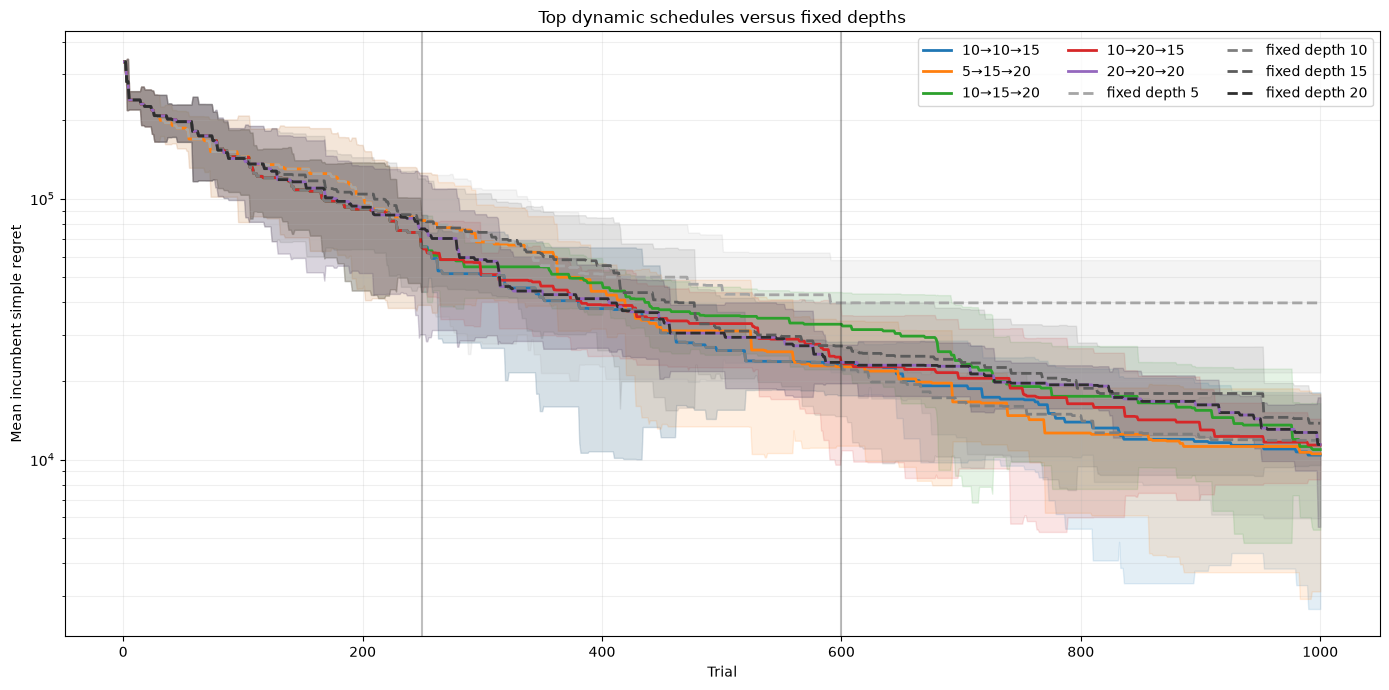

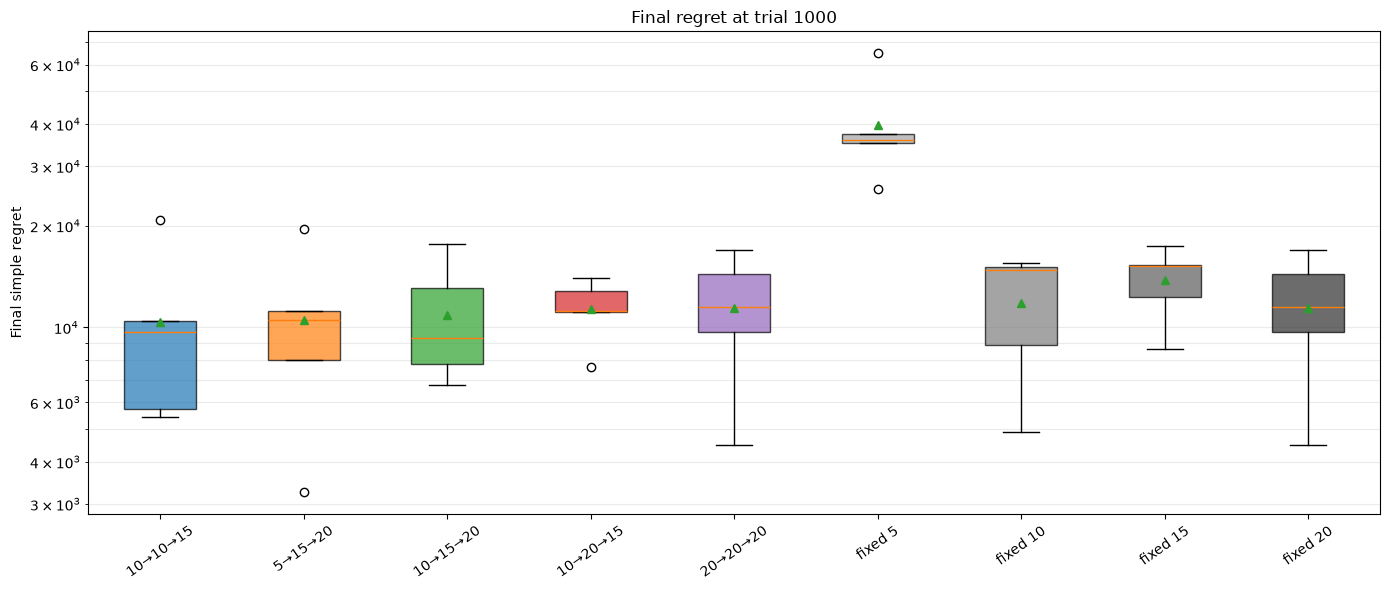

In [6]:
if len(complete_fixed) != 4: raise ValueError('Wait for all four fixed baselines to complete.')
policies = [('policies', p) for p in top5.policy] + [('fixed', f'fixed_depth_{d}') for d in DEPTHS]
def matrix(family, policy): return np.vstack([curves[(family, policy, seed)] for seed in SEEDS])
colors = list(plt.cm.tab10(np.linspace(0,.4,5))) + list(plt.cm.Greys(np.linspace(.45,.85,4)))
fig, ax = plt.subplots(figsize=(14,7))
for i, (family, policy) in enumerate(policies):
    m = matrix(family, policy); mean=m.mean(0); sem=m.std(0,ddof=1)/np.sqrt(5); margin=t.ppf(.975,4)*sem; x=np.arange(1,1001)
    label = policy.replace('depth_policy_','').replace('_','→') if family=='policies' else policy.replace('_',' ')
    ax.plot(x, np.maximum(mean,1e-300), color=colors[i], ls='-' if family=='policies' else '--', lw=2, label=label)
    ax.fill_between(x, np.maximum(mean-margin,1e-300), np.maximum(mean+margin,1e-300), color=colors[i], alpha=.12)
for boundary in (250,600): ax.axvline(boundary,color='black',alpha=.25)
ax.set_yscale('log'); ax.set_xlabel('Trial'); ax.set_ylabel('Mean incumbent simple regret'); ax.set_title('Top dynamic schedules versus fixed depths'); ax.grid(alpha=.2,which='both'); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

values=[matrix(f,p)[:,-1] for f,p in policies]
labels=[p.replace('depth_policy_','').replace('_','→') if f=='policies' else p.replace('fixed_depth_','fixed ') for f,p in policies]
fig,ax=plt.subplots(figsize=(14,6)); boxes=ax.boxplot(values,tick_labels=labels,showmeans=True,patch_artist=True)
for box,color in zip(boxes['boxes'],colors): box.set_facecolor(color); box.set_alpha(.7)
ax.set_yscale('log'); ax.set_ylabel('Final simple regret'); ax.set_title('Final regret at trial 1000'); ax.tick_params(axis='x',rotation=35); ax.grid(axis='y',alpha=.25,which='both')
plt.tight_layout(); plt.show()

## Additional diagnostics: policy landscape and constant-schedule reproducibility

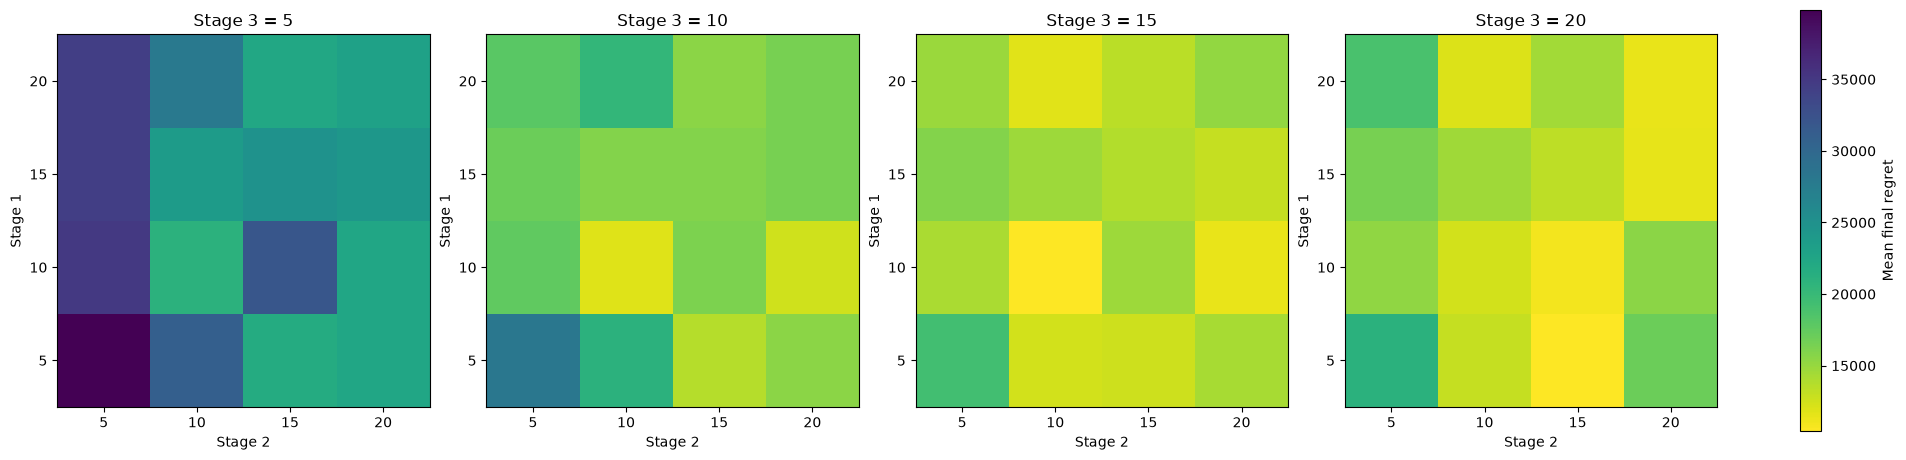

,depth,seed,identical,first_difference
0,5,0,True,None
1,5,1,True,None
2,5,2,True,None
3,5,3,True,None
4,5,4,True,None
5,10,0,True,None
6,10,1,True,None
7,10,2,True,None
8,10,3,True,None
9,10,4,True,None


Identical: 20/20


In [7]:
fig,axes=plt.subplots(1,4,figsize=(19,4.5),constrained_layout=True); vmin=summary.mean_final.min(); vmax=summary.mean_final.max()
for ax,d3 in zip(axes,DEPTHS):
    pivot=summary.query('d3==@d3').pivot(index='d1',columns='d2',values='mean_final').reindex(index=DEPTHS,columns=DEPTHS)
    image=ax.imshow(pivot,origin='lower',cmap='viridis_r',vmin=vmin,vmax=vmax); ax.set_xticks(range(4),DEPTHS); ax.set_yticks(range(4),DEPTHS); ax.set_xlabel('Stage 2'); ax.set_ylabel('Stage 1'); ax.set_title(f'Stage 3 = {d3}')
fig.colorbar(image,ax=axes,label='Mean final regret'); plt.show()

checks=[]
for depth in DEPTHS:
    for seed in SEEDS:
        a=('policies',f'depth_policy_{depth}_{depth}_{depth}',seed); b=('fixed',f'fixed_depth_{depth}',seed)
        if a in curves and b in curves:
            different=np.flatnonzero(curves[a] != curves[b]); checks.append({'depth':depth,'seed':seed,'identical':len(different)==0,'first_difference':None if len(different)==0 else int(different[0]+1)})
reproducibility=pd.DataFrame(checks); display(reproducibility)
if not reproducibility.empty: print(f"Identical: {reproducibility.identical.sum()}/{len(reproducibility)}")

## Paired comparison of the selected best dynamic and best fixed policy

In [8]:
fixed_summary=fixed[fixed.policy.isin(complete_fixed)].groupby('policy',as_index=False).agg(mean_final=('final_regret','mean'),std_final=('final_regret','std')).sort_values('mean_final'); display(fixed_summary)
best_dynamic=top5.iloc[0].policy; best_fixed=fixed_summary.iloc[0].policy
paired=(dynamic.query('policy==@best_dynamic')[['seed','final_regret']].rename(columns={'final_regret':'dynamic'})
    .merge(fixed.query('policy==@best_fixed')[['seed','final_regret']].rename(columns={'final_regret':'fixed'}),on='seed',validate='one_to_one'))
paired['difference']=paired.dynamic-paired.fixed; paired['relative_percent']=100*(paired.dynamic/paired.fixed-1)
print('Dynamic:',best_dynamic,'Fixed:',best_fixed); display(paired)
print(f"Dynamic wins {(paired.difference<0).sum()}/{len(paired)} seeds; mean relative change {paired.relative_percent.mean():.2f}%")

,policy,mean_final,std_final
2,fixed_depth_20,11416.309177,4748.481538
0,fixed_depth_10,11846.753856,4746.117032
1,fixed_depth_15,13778.376323,3427.258237
3,fixed_depth_5,39853.865712,14726.666510


Dynamic: depth_policy_10_10_15 Fixed: fixed_depth_20


,seed,dynamic,fixed,difference,relative_percent
0,0,10423.193522,16909.991832,-6486.798310,-38.360742
1,1,20772.829427,9717.597750,11055.231677,113.765068
2,2,9669.539650,14434.276639,-4764.736990,-33.009877
3,3,5416.953525,4487.770579,929.182946,20.704778
4,4,5717.210731,11531.909083,-5814.698353,-50.422686


Dynamic wins 3/5 seeds; mean relative change 2.54%
